In [1]:
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from config import DRILLING_ADVISORY_ARTIFACT_DIR, DRILLING_ADVISORY_REPORT_DIR

ARTIFACT_DIR = Path(DRILLING_ADVISORY_ARTIFACT_DIR)
REPORT_DIR = Path(DRILLING_ADVISORY_REPORT_DIR)

ANALYSIS_DIR = PROJECT_ROOT / "notebooks" / "well_performance_analysis_reports"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

WELL_REPORT_PATH = ARTIFACT_DIR / "well_level_time_report_near5_non_overlap.csv"
BLOCK_REPORT_PATH = ARTIFACT_DIR / "block_level_time_report_near5_non_overlap.csv"

if not WELL_REPORT_PATH.exists():
    WELL_REPORT_PATH = ANALYSIS_DIR / "well_level_time_report_near5_non_overlap.csv"

if not BLOCK_REPORT_PATH.exists():
    BLOCK_REPORT_PATH = ANALYSIS_DIR / "block_level_time_report_near5_non_overlap.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("WELL_REPORT_PATH:", WELL_REPORT_PATH)
print("BLOCK_REPORT_PATH:", BLOCK_REPORT_PATH)
EXCEL_REPORT_PATH = ANALYSIS_DIR / "well_performance_analysis_report.xlsx"
print("ANALYSIS_DIR:", ANALYSIS_DIR)
print("EXCEL_REPORT_PATH:", EXCEL_REPORT_PATH)

PROJECT_ROOT: C:\Users\qa1ro\OneDrive\Рабочий стол\diploma\OptimalDrilling
WELL_REPORT_PATH: C:\Users\qa1ro\OneDrive\Рабочий стол\diploma\OptimalDrilling\notebooks\drilling_advisory_light_penalty_artifacts\well_level_time_report_near5_non_overlap.csv
BLOCK_REPORT_PATH: C:\Users\qa1ro\OneDrive\Рабочий стол\diploma\OptimalDrilling\notebooks\drilling_advisory_light_penalty_artifacts\block_level_time_report_near5_non_overlap.csv
ANALYSIS_DIR: C:\Users\qa1ro\OneDrive\Рабочий стол\diploma\OptimalDrilling\notebooks\well_performance_analysis_reports
EXCEL_REPORT_PATH: C:\Users\qa1ro\OneDrive\Рабочий стол\diploma\OptimalDrilling\notebooks\well_performance_analysis_reports\well_performance_analysis_report.xlsx


In [2]:
# Human-readable column names for the Excel report.
COLUMN_RENAME = {
    "well_id": "Скважина",
    "performance_type": "Тип результата модели",
        "wells": "Количество скважин",
    "share": "Доля скважин",
    "operator_time_min": "Время оператора, мин",
    "model_time_min": "Расчётное время модели, мин",
    "operator_time_total_min": "Суммарное время оператора, мин",
    "model_time_total_min": "Суммарное расчётное время модели, мин",
    "time_saved_min": "Расчётная экономия времени, мин",
    "time_saved_total_min": "Суммарная расчётная экономия, мин",
    "time_saved_pct": "Расчётная экономия времени, %",
    "time_saved_total_pct": "Суммарная расчётная экономия, %",
    "median_time_saved_pct": "Медианная экономия времени, %",
    "mean_time_saved_pct": "Средняя экономия времени, %",
    "p05_time_saved_pct": "5-й перцентиль экономии, %",
    "p25_time_saved_pct": "25-й перцентиль экономии, %",
    "p75_time_saved_pct": "75-й перцентиль экономии, %",
    "p95_time_saved_pct": "95-й перцентиль экономии, %",
    "telemetry_rows_covered": "Строк телеметрии в расчёте",
    "non_overlap_blocks": "Непересекающихся интервалов near_5",
    "total_depth_modeled_m": "Суммарная проходка, м",
    "operator_block_speed_mean": "Средняя скорость оператора по интервалам, м/с",
    "current_predicted_speed_mean": "Прогноз скорости текущего режима, м/с",
    "recommended_predicted_speed_mean": "Прогноз скорости рекомендации, м/с",
    "model_based_predicted_uplift_pct_median": "Медианный прогнозируемый uplift модели, %",
    "predicted_regret_vs_operator_pct_median": "Медианное отличие рекомендации от факта оператора, %",
    "recommended_win_vs_operator_rate": "Доля интервалов, где рекомендация выше факта",
    "current_pressure_axis_mean": "Среднее текущее осевое давление",
    "recommended_pressure_axis_mean": "Среднее рекомендованное осевое давление",
    "current_pressure_rotation_mean": "Среднее текущее давление вращения",
    "recommended_pressure_rotation_mean": "Среднее рекомендованное давление вращения",
    "recommended_axis_delta_pct_mean": "Среднее изменение осевого давления, %",
    "recommended_rotation_pressure_delta_pct_mean": "Среднее изменение давления вращения, %",
    "soft_low_energy_pct": "Доля мягкой низкоэнергоёмкой породы, %",
    "medium_low_energy_pct": "Доля средней низкоэнергоёмкой породы, %",
    "medium_high_energy_pct": "Доля средней высокоэнергоёмкой породы, %",
    "hard_high_energy_pct": "Доля твёрдой высокоэнергоёмкой породы, %",
    "feature": "Признак",
    "negative_median": "Медиана в группе negative",
    "strong_positive_median": "Медиана в группе strong_positive",
    "difference_strong_minus_negative": "Разница strong_positive − negative",
    "abs_difference": "Абсолютная разница",
    "blocks": "Количество интервалов near_5",
    "positive_block_rate": "Доля интервалов с положительной экономией",
    "strong_positive_block_rate": "Доля интервалов с экономией > 5%",
    "negative_block_rate": "Доля интервалов с отрицательной экономией",
    "block_time_saved_pct_std": "Стандартное отклонение экономии по интервалам, %",
    "block_time_saved_pct_median": "Медианная экономия по интервалам, %",
            "median_total_depth": "Медианная проходка, м",
    "median_operator_speed": "Медианная скорость оператора, м/с",
    "median_model_uplift": "Медианный uplift модели, %",
    "median_regret_vs_operator": "Медианное отличие рекомендации от факта, %",
    "median_win_rate": "Медианная доля выигрышных интервалов",
    "soft_pct": "Доля soft, %",
    "medium_low_pct": "Доля medium_low, %",
    "medium_high_pct": "Доля medium_high, %",
    "hard_pct": "Доля hard, %",
    "distance_to_type_median": "Расстояние до медианы типа",
}


FEATURE_TRANSLATION = {
    "telemetry_rows_covered": "Строк телеметрии в расчёте",
    "non_overlap_blocks": "Непересекающихся интервалов near_5",
    "total_depth_modeled_m": "Суммарная проходка, м",
    "operator_time_min": "Время оператора, мин",
    "operator_block_speed_mean": "Средняя скорость оператора по интервалам, м/с",
    "current_predicted_speed_mean": "Прогноз скорости текущего режима, м/с",
    "recommended_predicted_speed_mean": "Прогноз скорости рекомендации, м/с",
    "model_based_predicted_uplift_pct_median": "Медианный прогнозируемый uplift модели, %",
    "predicted_regret_vs_operator_pct_median": "Медианное отличие рекомендации от факта оператора, %",
    "recommended_win_vs_operator_rate": "Доля интервалов, где рекомендация выше факта",
    "current_pressure_axis_mean": "Среднее текущее осевое давление",
    "recommended_pressure_axis_mean": "Среднее рекомендованное осевое давление",
    "current_pressure_rotation_mean": "Среднее текущее давление вращения",
    "recommended_pressure_rotation_mean": "Среднее рекомендованное давление вращения",
    "soft_low_energy_pct": "Доля мягкой низкоэнергоёмкой породы, %",
    "medium_low_energy_pct": "Доля средней низкоэнергоёмкой породы, %",
    "medium_high_energy_pct": "Доля средней высокоэнергоёмкой породы, %",
    "hard_high_energy_pct": "Доля твёрдой высокоэнергоёмкой породы, %",
    "time_saved_pct": "Расчётная экономия времени, %",
}

TYPE_TRANSLATION = {
    "negative": "Отрицательный эффект",
    "neutral": "Нейтральный эффект",
    "moderate_positive": "Умеренно положительный эффект",
    "strong_positive": "Сильно положительный эффект",
}

# Additional names after MultiIndex flattening.
COLUMN_RENAME.update({
    "Тип результата модели ": "Тип результата модели",
    "time_saved_pct median": "Медианная экономия времени, %",
    "time_saved_pct mean": "Средняя экономия времени, %",
    "block_time_saved_pct median": "Медианная экономия интервала, %",
    "block_time_saved_pct mean": "Средняя экономия интервала, %",
    "model_based_predicted_uplift_pct median": "Медианный прогнозируемый uplift модели, %",
    "model_based_predicted_uplift_pct mean": "Средний прогнозируемый uplift модели, %",
    "predicted_regret_vs_operator_pct median": "Медианное отличие рекомендации от факта оператора, %",
    "predicted_regret_vs_operator_pct mean": "Среднее отличие рекомендации от факта оператора, %",
    "recommended_win_vs_operator median": "Медианная доля выигрыша рекомендации над фактом",
    "recommended_win_vs_operator mean": "Средняя доля выигрыша рекомендации над фактом",
    "operator_block_speed median": "Медианная скорость оператора на интервале, м/с",
    "operator_block_speed mean": "Средняя скорость оператора на интервале, м/с",
    "recommended_predicted_speed median": "Медианная прогнозная скорость рекомендации, м/с",
    "recommended_predicted_speed mean": "Средняя прогнозная скорость рекомендации, м/с",
    "current_predicted_target_speed median": "Медианная прогнозная скорость текущего режима, м/с",
    "current_predicted_target_speed mean": "Средняя прогнозная скорость текущего режима, м/с",
    "block_depth_m median": "Медианная проходка интервала, м",
    "block_depth_m mean": "Средняя проходка интервала, м",
    "operator_block_time_sec median": "Медианное время оператора на интервале, с",
    "operator_block_time_sec mean": "Среднее время оператора на интервале, с",
})




COLUMN_RENAME.update({
    "intervals_count": "Количество интервалов near_5",
    "interval_time_saved_pct_median": "Медианная экономия по интервалам, %",
    "interval_time_saved_pct_mean": "Средняя экономия по интервалам, %",
    "interval_model_uplift_pct_median": "Медианный uplift модели по интервалам, %",
    "interval_regret_vs_operator_pct_median": "Медианное отличие рекомендации от факта по интервалам, %",
    "interval_recommendation_win_rate": "Доля интервалов, где рекомендация выше факта",
    "operator_interval_speed_mean": "Средняя скорость оператора по интервалам, м/с",
    "recommended_interval_speed_mean": "Средняя прогнозная скорость рекомендации по интервалам, м/с",
})

def make_excel_friendly(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for col in out.columns:
        if str(out[col].dtype) == "category":
            out[col] = out[col].astype(str)

    for col in out.columns:
        if "performance_type" in str(col):
            out[col] = out[col].replace(TYPE_TRANSLATION)

    # Flatten MultiIndex columns if present.
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = [
            " ".join([str(part) for part in col if str(part) != ""]).strip()
            for col in out.columns
        ]

    out = out.rename(columns=COLUMN_RENAME)

    # Remove duplicated columns after renaming, if any.
    out = out.loc[:, ~out.columns.duplicated()].copy()
    return out


def add_sheet(report_tables: dict, sheet_name: str, df: pd.DataFrame):
    report_tables[sheet_name] = make_excel_friendly(df)


report_tables = {}

In [3]:
well_df = pd.read_csv(WELL_REPORT_PATH)

date_cols = ["drilling_start", "drilling_end"]
for col in date_cols:
    if col in well_df.columns:
        well_df[col] = pd.to_datetime(well_df[col], errors="coerce")

print("Well report:", well_df.shape)
display(well_df.head())
display(well_df.describe(percentiles=[.05, .25, .5, .75, .95]))

Well report: (427, 24)


,well_id,non_overlap_blocks,telemetry_rows_covered,drilling_start,drilling_end,total_depth_modeled_m,soft_low_energy_pct,medium_low_energy_pct,medium_high_energy_pct,hard_high_energy_pct,...,operator_block_speed_mean,current_predicted_speed_mean,recommended_predicted_speed_mean,model_based_predicted_uplift_pct_median,predicted_regret_vs_operator_pct_median,recommended_win_vs_operator_rate,current_pressure_axis_mean,recommended_pressure_axis_mean,current_pressure_rotation_mean,recommended_pressure_rotation_mean
0,19677,40,200,2025-08-25 00:11:42.917,2025-08-25 00:29:08.045,18.0891,100.000000,0.000000,0.000000,0.000000,...,0.017199,0.016887,0.017024,0.789060,-4.054483,0.425000,16549.525000,16684.858800,14128.700000,14239.297800
1,19720,67,335,2025-08-25 06:05:23.654,2025-08-25 06:38:46.469,15.9378,0.000000,0.000000,15.209125,84.790875,...,0.008870,0.008893,0.009195,3.037454,3.853629,0.537313,18629.059701,18641.328045,13733.283582,14424.979224
2,19775,53,265,2025-08-25 20:58:19.756,2025-08-25 21:32:14.931,16.5741,30.164534,21.023766,7.678245,41.133455,...,0.011622,0.011333,0.011690,3.192097,8.266529,0.622642,15025.792453,15380.527245,13136.056604,13642.401698
3,19780,44,220,2025-08-25 21:40:22.712,2025-08-25 22:06:37.467,17.1195,28.672566,71.327434,0.000000,0.000000,...,0.014795,0.013776,0.014093,1.791956,0.489961,0.522727,14336.818182,14601.719455,13712.340909,13887.276750
4,19789,49,245,2025-08-25 22:54:47.204,2025-08-25 23:25:58.302,16.8468,51.079137,21.402878,27.517986,0.000000,...,0.012756,0.013425,0.013687,1.818817,7.082355,0.632653,15383.857143,15520.782133,13863.408163,14125.691306


,well_id,non_overlap_blocks,telemetry_rows_covered,drilling_start,drilling_end,total_depth_modeled_m,soft_low_energy_pct,medium_low_energy_pct,medium_high_energy_pct,hard_high_energy_pct,...,operator_block_speed_mean,current_predicted_speed_mean,recommended_predicted_speed_mean,model_based_predicted_uplift_pct_median,predicted_regret_vs_operator_pct_median,recommended_win_vs_operator_rate,current_pressure_axis_mean,recommended_pressure_axis_mean,current_pressure_rotation_mean,recommended_pressure_rotation_mean
count,427.000000,427.000000,427.000000,427,427,427.000000,427.000000,427.000000,427.000000,427.000000,...,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000
mean,24781.039813,45.533958,227.669789,2025-10-01 03:40:11.547857,2025-10-01 04:06:22.896154,16.612489,35.148941,26.020627,20.380335,18.450097,...,0.014116,0.014244,0.014518,1.966358,5.467244,0.591464,17717.089734,17666.381254,14323.704132,14713.948624
min,19677.000000,6.000000,30.000000,2025-08-25 00:11:42.917000,2025-08-25 00:29:08.045000,2.727000,0.000000,0.000000,0.000000,0.000000,...,0.005953,0.006890,0.007424,0.075597,-14.860029,0.263158,6965.100000,6797.781000,8370.850000,8582.018538
5%,20234.000000,17.000000,85.000000,2025-08-29 01:34:48.193500,2025-08-29 02:13:22.551800,7.826490,0.000000,0.000000,0.000000,0.000000,...,0.008243,0.008848,0.009156,0.433095,-4.306509,0.405659,13149.320000,13463.106857,11181.300962,11268.055772
25%,22132.000000,29.000000,145.000000,2025-09-13 20:32:12.226500,2025-09-13 20:51:38.837500,13.528950,0.000000,0.000000,0.000000,0.000000,...,0.010750,0.011275,0.011544,1.026513,1.069070,0.527047,16104.370502,16230.969427,13120.597746,13616.732792
50%,24010.000000,44.000000,220.000000,2025-09-26 19:51:05.419000,2025-09-26 20:13:19.641000,16.119600,21.816038,20.942408,12.738095,0.000000,...,0.013773,0.014007,0.014324,1.699702,4.453714,0.596639,18114.840000,18050.139412,14440.657143,14849.473127
75%,27608.000000,59.000000,295.000000,2025-10-21 14:15:11.732500,2025-10-21 14:30:52.835000,18.982950,67.491781,46.926523,34.774734,32.891805,...,0.016691,0.016691,0.016920,2.661700,9.150179,0.671642,19692.461622,19553.203616,15667.876080,16160.408300
95%,30925.300000,81.700000,408.500000,2025-11-07 13:11:03.623000,2025-11-07 15:14:16.985900,25.555020,100.000000,80.867052,73.295331,84.051932,...,0.021588,0.020848,0.021105,4.201662,18.194795,0.750000,21258.120567,20895.463918,16879.532381,17359.418798
max,31923.000000,119.000000,595.000000,2025-11-11 12:51:00.346000,2025-11-11 13:10:13.092000,44.510700,100.000000,100.000000,100.000000,100.000000,...,0.031398,0.028919,0.027495,9.066914,31.836055,0.937500,22820.555556,21755.871672,19202.657895,19020.603895
std,3351.666721,20.596518,102.982592,NaN,NaN,5.334779,38.478934,28.083660,25.825664,29.004553,...,0.004196,0.003807,0.003744,1.219968,6.805176,0.110700,2640.301948,2461.900437,1831.752480,1882.866744


In [4]:
if BLOCK_REPORT_PATH.exists():
    block_df = pd.read_csv(BLOCK_REPORT_PATH)
    for col in ["processing_time", "block_start", "block_end"]:
        if col in block_df.columns:
            block_df[col] = pd.to_datetime(block_df[col], errors="coerce")

    print("Block report:", block_df.shape)
    display(block_df.head())
else:
    block_df = None
    print("Block report not found; block-level diagnostics will be skipped.")

Block report: (19443, 100)


,processing_time,depth,d_depth,d_time,rotation,pressure_axis,pressure_rotation,well_id,speed,dt,...,current_predicted_target_speed,recommended_predicted_speed_clipped,model_block_time_sec,operator_block_time_min,model_block_time_min,block_time_saved_min,block_time_saved_pct,model_based_predicted_uplift_pct,predicted_regret_vs_operator_pct,recommended_win_vs_operator
0,2025-08-25 00:11:38.315,3.3633,0.0909,5.0,104.154,8587,10386,19677,0.01818,5.0,...,0.019454,0.019929,27.366472,0.450000,0.456108,-0.006108,-1.357303,2.442547,-1.339136,False
1,2025-08-25 00:12:02.240,3.9087,0.0606,5.0,105.084,8580,9226,19677,0.01212,5.0,...,0.016532,0.016949,26.814973,0.500000,0.446916,0.053084,10.616756,2.525853,11.877779,True
2,2025-08-25 00:12:31.700,4.3632,0.0303,5.0,103.854,8578,10116,19677,0.00606,5.0,...,0.012370,0.012381,26.920597,0.433333,0.448677,-0.015343,-3.540756,0.090599,-3.419689,False
3,2025-08-25 00:12:56.143,4.6965,0.0909,5.0,103.260,14741,10841,19677,0.01818,5.0,...,0.014651,0.014789,32.781729,0.433333,0.546362,-0.113029,-26.083572,0.941857,-20.687536,False
4,2025-08-25 00:13:24.785,5.1813,0.1212,5.0,102.564,17291,15438,19677,0.02424,5.0,...,0.019680,0.019680,21.554781,0.433333,0.359246,0.074087,17.096995,-0.000005,20.622876,True


## 1. Базовая проверка распределения экономии

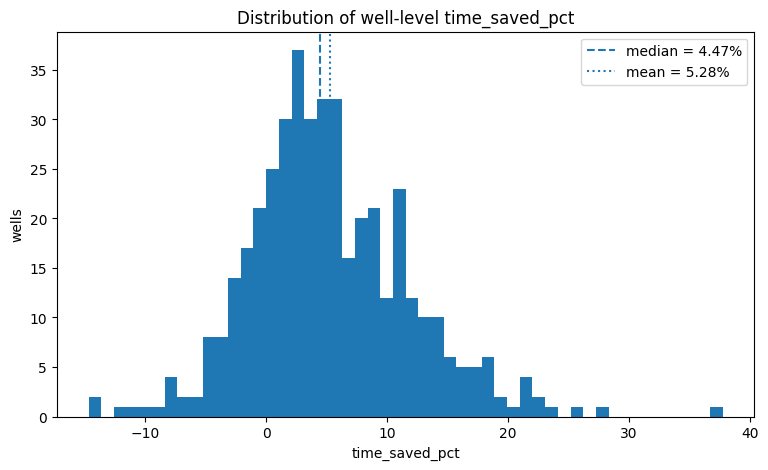

,wells,operator_time_total_min,model_time_total_min,time_saved_total_min,time_saved_total_pct,median_time_saved_pct,mean_time_saved_pct,p05_time_saved_pct,p25_time_saved_pct,p75_time_saved_pct,p95_time_saved_pct
0,427,9493.483333,8848.038115,645.445219,6.798824,4.466032,5.284953,-4.200764,1.003417,9.05618,17.225654


In [5]:
main_metric = "time_saved_pct"

fig = plt.figure(figsize=(9, 5))
plt.hist(well_df[main_metric].dropna(), bins=50)
plt.axvline(well_df[main_metric].median(), linestyle="--", label=f"median = {well_df[main_metric].median():.2f}%")
plt.axvline(well_df[main_metric].mean(), linestyle=":", label=f"mean = {well_df[main_metric].mean():.2f}%")
plt.title("Distribution of well-level time_saved_pct")
plt.xlabel("time_saved_pct")
plt.ylabel("wells")
plt.legend()
plt.show()

summary = pd.DataFrame([{
    "wells": len(well_df),
    "operator_time_total_min": well_df["operator_time_min"].sum(),
    "model_time_total_min": well_df["model_time_min"].sum(),
    "time_saved_total_min": well_df["time_saved_min"].sum(),
    "time_saved_total_pct": 100 * well_df["time_saved_min"].sum() / (well_df["operator_time_min"].sum() + 1e-9),
    "median_time_saved_pct": well_df["time_saved_pct"].median(),
    "mean_time_saved_pct": well_df["time_saved_pct"].mean(),
    "p05_time_saved_pct": well_df["time_saved_pct"].quantile(0.05),
    "p25_time_saved_pct": well_df["time_saved_pct"].quantile(0.25),
    "p75_time_saved_pct": well_df["time_saved_pct"].quantile(0.75),
    "p95_time_saved_pct": well_df["time_saved_pct"].quantile(0.95),
}])

display(summary)
add_sheet(report_tables, "00_Сводка", summary)

## 2. Правило типизации скважин по результату модели

In [6]:
def assign_performance_type(time_saved_pct: float) -> str:
    if time_saved_pct >= 10.0:
        return "strong_positive"
    if time_saved_pct >= 3.0:
        return "moderate_positive"
    if time_saved_pct >= -3.0:
        return "neutral"
    return "negative"


well_df["performance_type"] = well_df["time_saved_pct"].apply(assign_performance_type)

type_order = ["negative", "neutral", "moderate_positive", "strong_positive"]
well_df["performance_type"] = pd.Categorical(well_df["performance_type"], categories=type_order, ordered=True)

type_counts = (
    well_df
    .groupby("performance_type", observed=False)
    .agg(
        wells=("well_id", "size"),
        share=("well_id", lambda s: len(s) / len(well_df)),
        operator_time_min=("operator_time_min", "sum"),
        model_time_min=("model_time_min", "sum"),
        time_saved_min=("time_saved_min", "sum"),
        median_time_saved_pct=("time_saved_pct", "median"),
        mean_time_saved_pct=("time_saved_pct", "mean"),
    )
    .reset_index()
)

type_counts["time_saved_total_pct"] = 100 * (
    type_counts["time_saved_min"]
    / (type_counts["operator_time_min"] + 1e-9)
)

display(type_counts)

# Excel sheet is created later after merging with pressure and interval summaries.

,performance_type,wells,share,operator_time_min,model_time_min,time_saved_min,median_time_saved_pct,mean_time_saved_pct,time_saved_total_pct
0,negative,31,0.072600,357.866667,378.521381,-20.654715,-5.109050,-6.349370,-5.771623
1,neutral,137,0.320843,2428.566667,2409.593778,18.972889,0.557305,0.514154,0.781238
2,moderate_positive,163,0.381733,3928.183333,3686.936849,241.246484,5.710412,5.975089,6.141426
3,strong_positive,96,0.224824,2778.866667,2372.986107,405.880560,13.109040,14.678405,14.605975


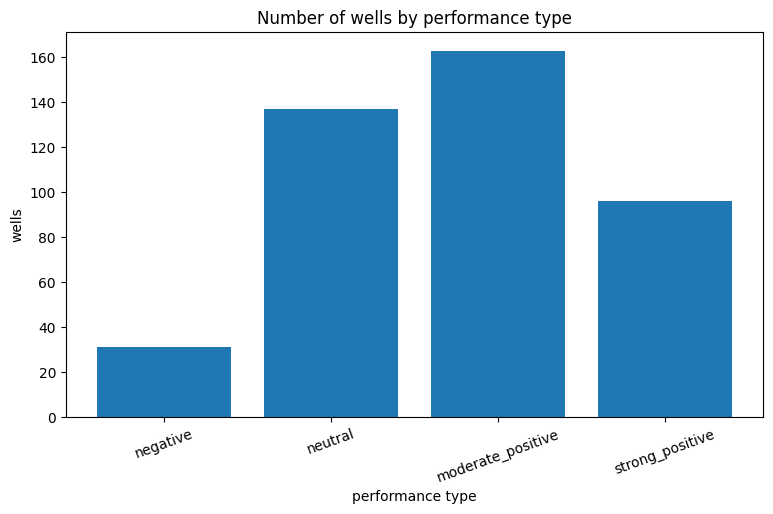

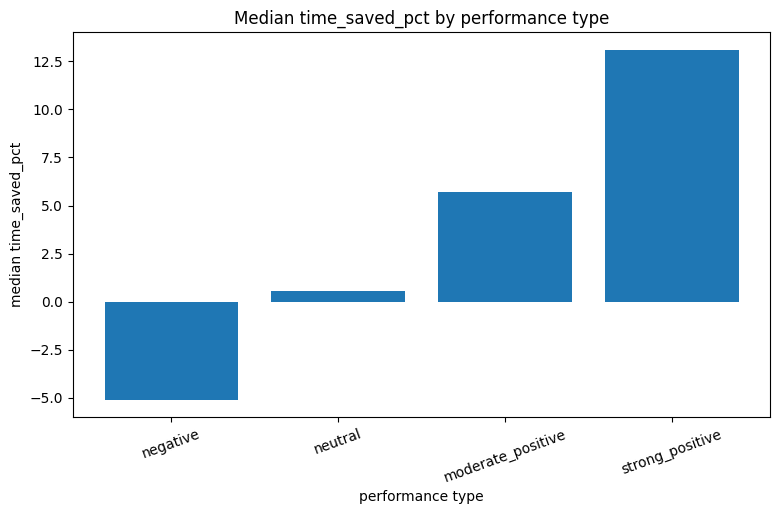

In [7]:
fig = plt.figure(figsize=(9, 5))
plt.bar(type_counts["performance_type"].astype(str), type_counts["wells"])
plt.title("Number of wells by performance type")
plt.xlabel("performance type")
plt.ylabel("wells")
plt.xticks(rotation=20)
plt.show()

fig = plt.figure(figsize=(9, 5))
plt.bar(type_counts["performance_type"].astype(str), type_counts["median_time_saved_pct"])
plt.title("Median time_saved_pct by performance type")
plt.xlabel("performance type")
plt.ylabel("median time_saved_pct")
plt.xticks(rotation=20)
plt.show()

## 3. Чем отличаются типы скважин

In [8]:
energy_cols = [
    "soft_low_energy_pct",
    "medium_low_energy_pct",
    "medium_high_energy_pct",
    "hard_high_energy_pct",
]

candidate_numeric_cols = [
    "telemetry_rows_covered",
    "non_overlap_blocks",
    "total_depth_modeled_m",
    "operator_time_min",
    "operator_block_speed_mean",
    "current_predicted_speed_mean",
    "recommended_predicted_speed_mean",
    "model_based_predicted_uplift_pct_median",
    "predicted_regret_vs_operator_pct_median",
    "recommended_win_vs_operator_rate",
    "current_pressure_axis_mean",
    "recommended_pressure_axis_mean",
    "current_pressure_rotation_mean",
    "recommended_pressure_rotation_mean",
    *energy_cols,
]

numeric_cols = [col for col in candidate_numeric_cols if col in well_df.columns]

type_profile = (
    well_df
    .groupby("performance_type", observed=False)[numeric_cols + ["time_saved_pct"]]
    .agg(["median", "mean"])
)

display(type_profile)

# A compact median-only table.
type_profile_median = (
    well_df
    .groupby("performance_type", observed=False)[numeric_cols + ["time_saved_pct"]]
    .median()
    .reset_index()
)

display(type_profile_median)


telemetry_rows_covered             non_overlap_blocks  \
                                  median        mean             median   
performance_type                                                          
negative                           130.0  128.548387               26.0   
neutral                            185.0  189.890511               37.0   
moderate_positive                  240.0  251.012270               48.0   
strong_positive                    290.0  273.958333               58.0   

                             total_depth_modeled_m             \
                        mean                median       mean   
performance_type                                                
negative           25.709677              13.93800  13.784545   
neutral            37.978102              15.72570  16.817606   
moderate_positive  50.202454              16.60440  17.621216   
strong_positive    54.791667              16.31655  15.520228   

                  operator_time_min            operator_block_speed_mean  \
                             median       mean                    median   
performance_type                                                           
negative                  12.066667  11.544086                  0.020947   
neutral                   17.066667  17.726764                  0.016226   
moderate_positive         23.800000  24.099284                  0.012717   
strong_positive           30.258333  28.946528                  0.009487   

                             ... soft_low_energy_pct             \
                       mean  ...              median       mean   
performance_type             ...                                  
negative           0.020924  ...           100.00000  82.937072   
neutral            0.016555  ...            45.37037  49.513624   
moderate_positive  0.013066  ...             0.00000  23.342661   
strong_positive    0.010220  ...             0.00000  19.263837   

                  medium_low_energy_pct            medium_high_energy_pct  \
                                 median       mean                 median   
performance_type                                                            
negative                       0.000000  14.169819               0.000000   
neutral                       24.376200  29.502247               0.000000   
moderate_positive             27.586207  30.276294              22.395833   
strong_positive                0.000000  17.653120              16.083401   

                             hard_high_energy_pct            time_saved_pct  \
                        mean               median       mean         median   
performance_type                                                              
negative            2.893109             0.000000   0.000000      -5.109050   
neutral            15.539748             0.000000   5.444382       0.557305   
moderate_positive  27.939274             0.000000  18.441771       5.710412   
strong_positive    20.100725            40.798228  42.982318      13.109040   

                              
                        mean  
performance_type              
negative           -6.349370  
neutral             0.514154  
moderate_positive   5.975089  
strong_positive    14.678405  

[4 rows x 38 columns]

,performance_type,telemetry_rows_covered,non_overlap_blocks,total_depth_modeled_m,operator_time_min,operator_block_speed_mean,current_predicted_speed_mean,recommended_predicted_speed_mean,model_based_predicted_uplift_pct_median,predicted_regret_vs_operator_pct_median,recommended_win_vs_operator_rate,current_pressure_axis_mean,recommended_pressure_axis_mean,current_pressure_rotation_mean,recommended_pressure_rotation_mean,soft_low_energy_pct,medium_low_energy_pct,medium_high_energy_pct,hard_high_energy_pct,time_saved_pct
0,negative,130.0,26.0,13.93800,12.066667,0.020947,0.019333,0.019608,0.929489,-2.947633,0.428571,15065.434783,15424.520696,14208.285714,14292.285938,100.00000,0.000000,0.000000,0.000000,-5.109050
1,neutral,185.0,37.0,15.72570,17.066667,0.016226,0.016057,0.016293,1.171588,1.536276,0.542857,18302.758621,18264.951652,14779.425532,15328.618096,45.37037,24.376200,0.000000,0.000000,0.557305
2,moderate_positive,240.0,48.0,16.60440,23.800000,0.012717,0.013004,0.013311,1.979263,5.883684,0.616279,18768.104167,18645.706500,14620.106383,15184.615739,0.00000,27.586207,22.395833,0.000000,5.710412
3,strong_positive,290.0,58.0,16.31655,30.258333,0.009487,0.010214,0.010504,2.839947,13.345010,0.695652,17534.722029,17469.745058,13695.287500,14195.603811,0.00000,0.000000,16.083401,40.798228,13.109040


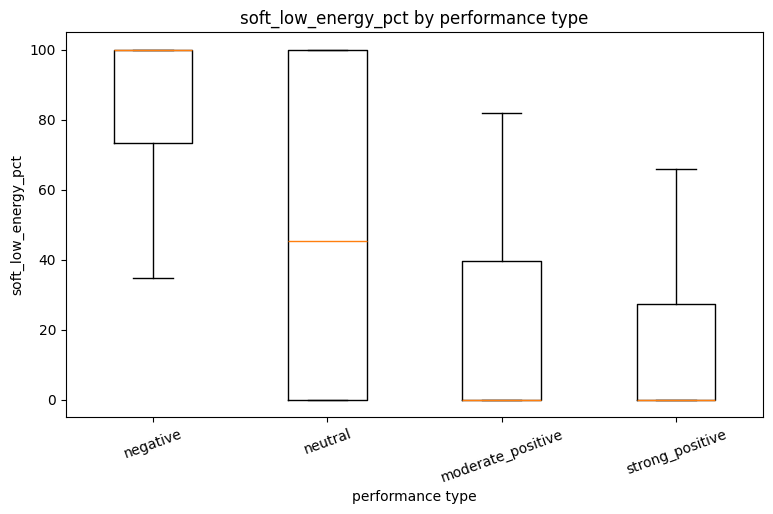

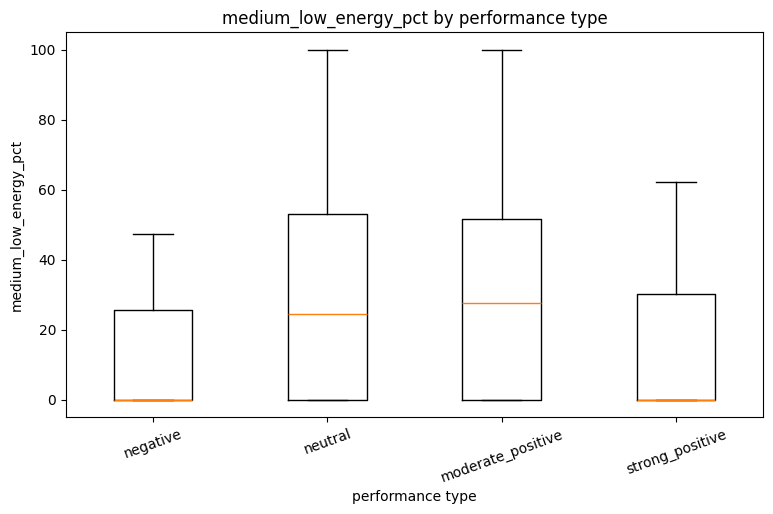

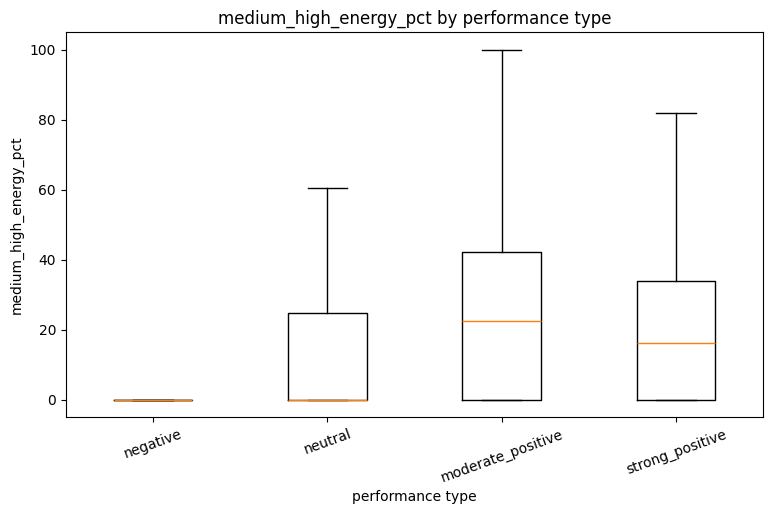

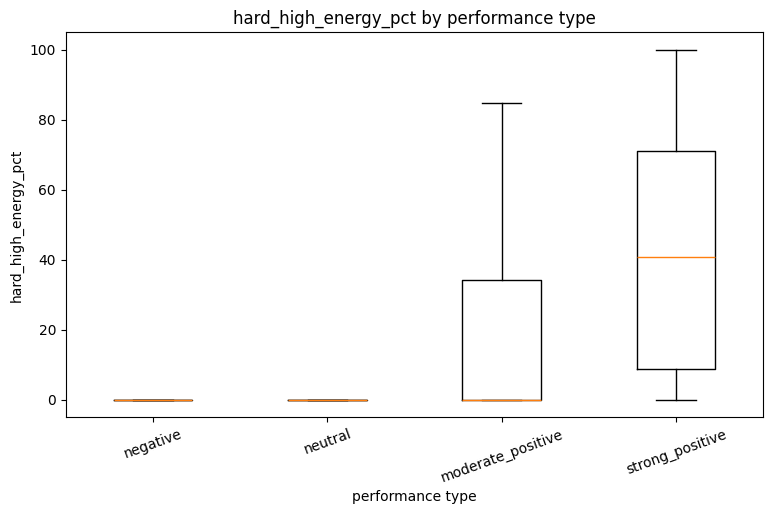

In [9]:
for col in energy_cols:
    if col in well_df.columns:
        fig = plt.figure(figsize=(9, 5))
        data = [
            well_df.loc[well_df["performance_type"] == t, col].dropna().to_numpy()
            for t in type_order
        ]
        plt.boxplot(data, labels=type_order, showfliers=False)
        plt.title(f"{col} by performance type")
        plt.xlabel("performance type")
        plt.ylabel(col)
        plt.xticks(rotation=20)
        plt.show()

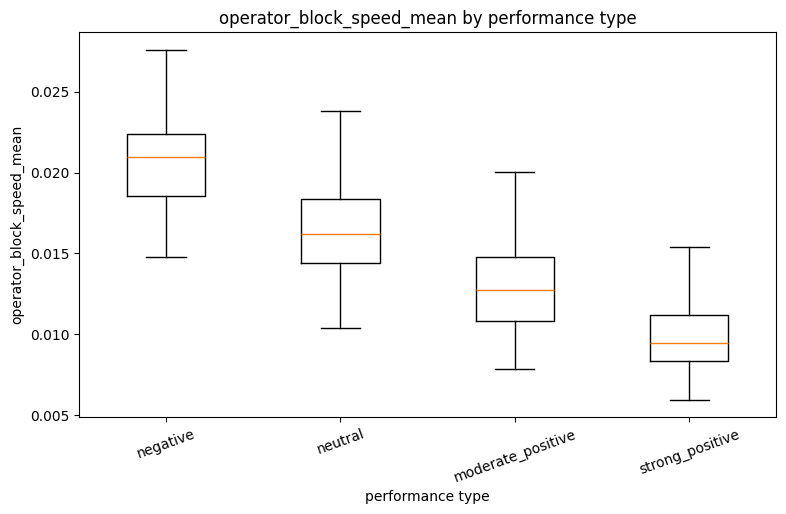

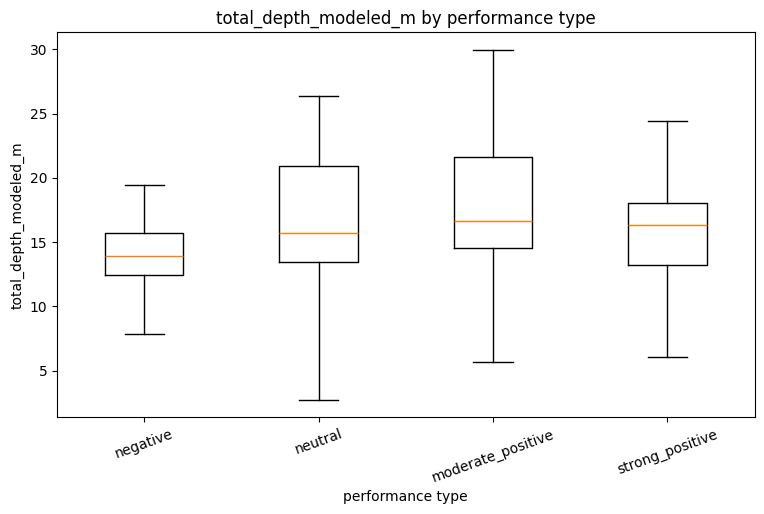

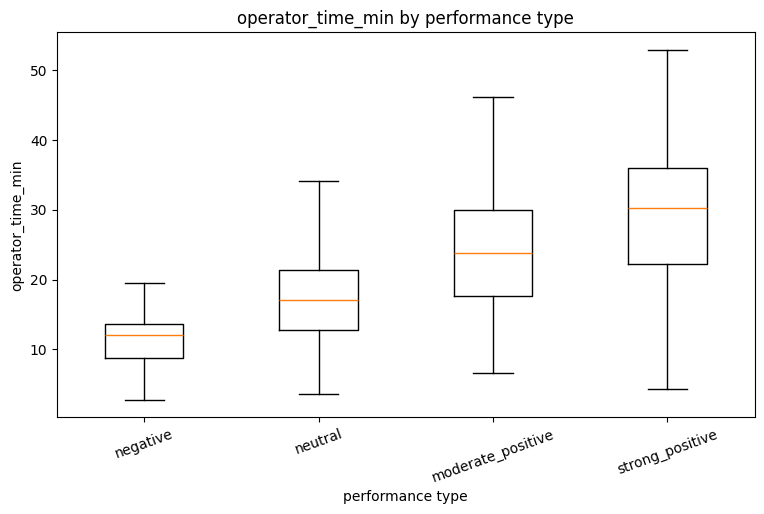

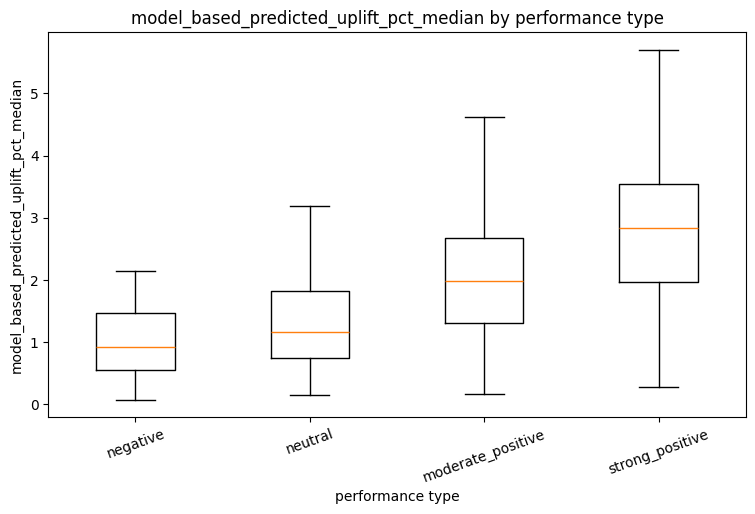

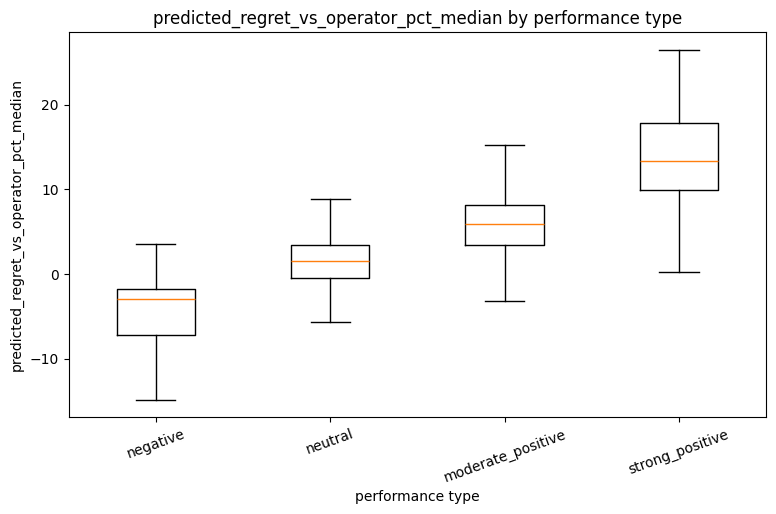

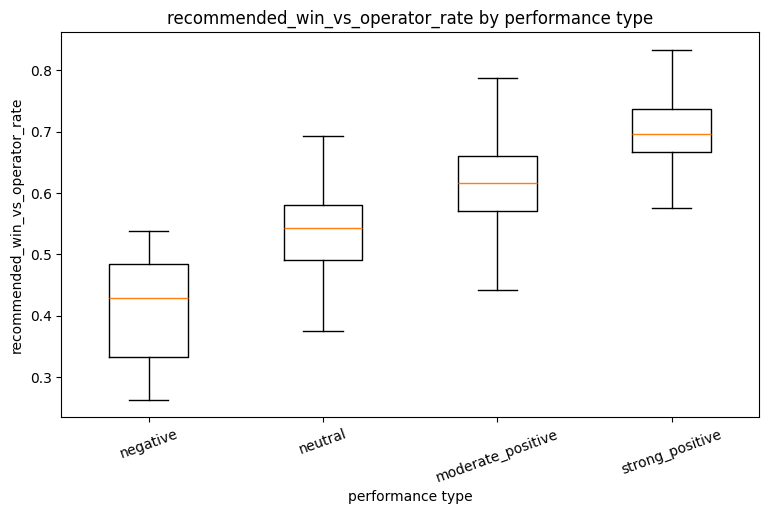

In [10]:
important_cols_for_boxplots = [
    "operator_block_speed_mean",
    "total_depth_modeled_m",
    "operator_time_min",
    "model_based_predicted_uplift_pct_median",
    "predicted_regret_vs_operator_pct_median",
    "recommended_win_vs_operator_rate",
]

for col in important_cols_for_boxplots:
    if col in well_df.columns:
        fig = plt.figure(figsize=(9, 5))
        data = [
            well_df.loc[well_df["performance_type"] == t, col].dropna().to_numpy()
            for t in type_order
        ]
        plt.boxplot(data, labels=type_order, showfliers=False)
        plt.title(f"{col} by performance type")
        plt.xlabel("performance type")
        plt.ylabel(col)
        plt.xticks(rotation=20)
        plt.show()

## 4. Анализ изменений давлений

,performance_type,recommended_axis_delta_pct_mean,recommended_rotation_pressure_delta_pct_mean,current_pressure_axis_mean,recommended_pressure_axis_mean,current_pressure_rotation_mean,recommended_pressure_rotation_mean
0,negative,1.847699,-0.439201,15065.434783,15424.520696,14208.285714,14292.285938
1,neutral,-0.064872,1.510384,18302.758621,18264.951652,14779.425532,15328.618096
2,moderate_positive,-0.477720,3.457257,18768.104167,18645.706500,14620.106383,15184.615739
3,strong_positive,-0.348228,4.278464,17534.722029,17469.745058,13695.287500,14195.603811


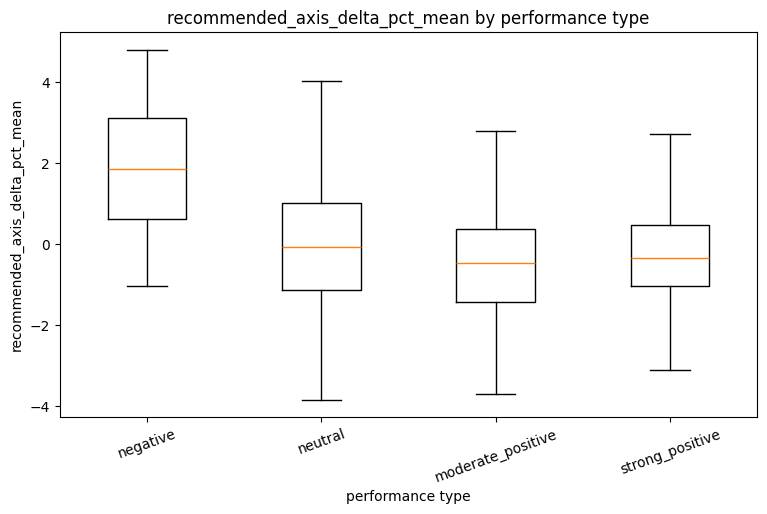

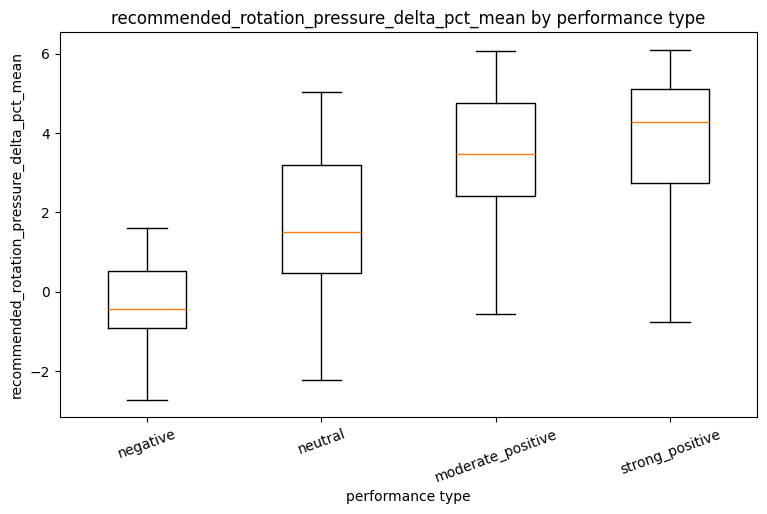

In [11]:
pressure_cols_required = [
    "current_pressure_axis_mean",
    "recommended_pressure_axis_mean",
    "current_pressure_rotation_mean",
    "recommended_pressure_rotation_mean",
]

if all(col in well_df.columns for col in pressure_cols_required):
    well_df["recommended_axis_delta_pct_mean"] = 100 * (
        well_df["recommended_pressure_axis_mean"] / (well_df["current_pressure_axis_mean"] + 1e-9) - 1
    )
    well_df["recommended_rotation_pressure_delta_pct_mean"] = 100 * (
        well_df["recommended_pressure_rotation_mean"] / (well_df["current_pressure_rotation_mean"] + 1e-9) - 1
    )

    pressure_profile = (
        well_df
        .groupby("performance_type", observed=False)[
            [
                "recommended_axis_delta_pct_mean",
                "recommended_rotation_pressure_delta_pct_mean",
                "current_pressure_axis_mean",
                "recommended_pressure_axis_mean",
                "current_pressure_rotation_mean",
                "recommended_pressure_rotation_mean",
            ]
        ]
        .median()
        .reset_index()
    )

    display(pressure_profile)
    # Merged into the combined type summary sheet later.

    for col in ["recommended_axis_delta_pct_mean", "recommended_rotation_pressure_delta_pct_mean"]:
        fig = plt.figure(figsize=(9, 5))
        data = [
            well_df.loc[well_df["performance_type"] == t, col].dropna().to_numpy()
            for t in type_order
        ]
        plt.boxplot(data, labels=type_order, showfliers=False)
        plt.title(f"{col} by performance type")
        plt.xlabel("performance type")
        plt.ylabel(col)
        plt.xticks(rotation=20)
        plt.show()
else:
    print("Pressure columns are missing; pressure analysis skipped.")

## Таблица всех скважин для Excel-отчёта

In [12]:
# Add all test wells as a separate Excel sheet.
# This must be after performance types and pressure deltas are calculated.

all_wells_cols = [
    "well_id",
    "performance_type",
    "time_saved_pct",
    "operator_time_min",
    "model_time_min",
    "time_saved_min",
    "total_depth_modeled_m",
    "non_overlap_blocks",
    "telemetry_rows_covered",
    "operator_block_speed_mean",
    "current_predicted_speed_mean",
    "recommended_predicted_speed_mean",
    "model_based_predicted_uplift_pct_median",
    "predicted_regret_vs_operator_pct_median",
    "recommended_win_vs_operator_rate",
    "current_pressure_axis_mean",
    "recommended_pressure_axis_mean",
    "recommended_axis_delta_pct_mean",
    "current_pressure_rotation_mean",
    "recommended_pressure_rotation_mean",
    "recommended_rotation_pressure_delta_pct_mean",
    "soft_low_energy_pct",
    "medium_low_energy_pct",
    "medium_high_energy_pct",
    "hard_high_energy_pct",
]

all_wells_cols = [col for col in all_wells_cols if col in well_df.columns]
all_wells_report = well_df[all_wells_cols].copy()

display(all_wells_report.head())
add_sheet(report_tables, "02_Все_скважины", all_wells_report)


,well_id,performance_type,time_saved_pct,operator_time_min,model_time_min,time_saved_min,total_depth_modeled_m,non_overlap_blocks,telemetry_rows_covered,operator_block_speed_mean,...,current_pressure_axis_mean,recommended_pressure_axis_mean,recommended_axis_delta_pct_mean,current_pressure_rotation_mean,recommended_pressure_rotation_mean,recommended_rotation_pressure_delta_pct_mean,soft_low_energy_pct,medium_low_energy_pct,medium_high_energy_pct,hard_high_energy_pct
0,19677,neutral,-1.911423,17.500000,17.834499,-0.334499,18.0891,40,200,0.017199,...,16549.525000,16684.858800,0.817750,14128.700000,14239.297800,0.782788,100.000000,0.000000,0.000000,0.000000
1,19720,moderate_positive,4.045857,30.233333,29.010136,1.223197,15.9378,67,335,0.008870,...,18629.059701,18641.328045,0.065856,13733.283582,14424.979224,5.036637,0.000000,0.000000,15.209125,84.790875
2,19775,neutral,0.383467,23.916667,23.824954,0.091713,16.5741,53,265,0.011622,...,15025.792453,15380.527245,2.360839,13136.056604,13642.401698,3.854620,30.164534,21.023766,7.678245,41.133455
3,19780,negative,-4.058808,19.500000,20.291467,-0.791467,17.1195,44,220,0.014795,...,14336.818182,14601.719455,1.847699,13712.340909,13887.276750,1.275755,28.672566,71.327434,0.000000,0.000000
4,19789,moderate_positive,8.923347,22.666667,20.644041,2.022625,16.8468,49,245,0.012756,...,15383.857143,15520.782133,0.890056,13863.408163,14125.691306,1.891910,51.079137,21.402878,27.517986,0.000000


## 5. Анализ непересекающихся интервалов внутри скважин

block_time_saved_pct             \
                                median       mean   
performance_type                                    
negative                     -3.711437  -6.134586   
neutral                       1.376683   0.188286   
moderate_positive             5.452786   4.560091   
strong_positive              11.897655  10.342654   

                  model_based_predicted_uplift_pct            \
                                            median      mean   
performance_type                                               
negative                                  0.974107  1.412402   
neutral                                   1.264868  1.821337   
moderate_positive                         2.127917  2.715552   
strong_positive                           2.971751  3.610778   

                  predicted_regret_vs_operator_pct             \
                                            median       mean   
performance_type                                                
negative                                 -3.469474  -1.260696   
neutral                                   1.395887   4.620980   
moderate_positive                         5.767254  10.732443   
strong_positive                          13.504312  22.219280   

                  recommended_win_vs_operator           operator_block_speed  \
                                       median      mean               median   
performance_type                                                               
negative                                  0.0  0.424090             0.019812   
neutral                                   1.0  0.539304             0.015150   
moderate_positive                         1.0  0.621288             0.011904   
strong_positive                           1.0  0.701901             0.008978   

                            recommended_predicted_speed            \
                       mean                      median      mean   
performance_type                                                    
negative           0.020010                    0.018885  0.019065   
neutral            0.015979                    0.015729  0.016047   
moderate_positive  0.012427                    0.012720  0.013019   
strong_positive    0.009563                    0.009886  0.010590   

                  current_predicted_target_speed           block_depth_m  \
                                          median      mean        median   
performance_type                                                           
negative                                0.018614  0.018814        0.5151   
neutral                                 0.015501  0.015793        0.4242   
moderate_positive                       0.012398  0.012722        0.3333   
strong_positive                         0.009569  0.010266        0.2424   

                            operator_block_time_sec             
                       mean                  median       mean  
performance_type                                                
negative           0.536162                    26.0  26.941029  
neutral            0.442824                    26.0  28.005766  
moderate_positive  0.351003                    26.0  28.802517  
strong_positive    0.283259                    27.0  31.698099

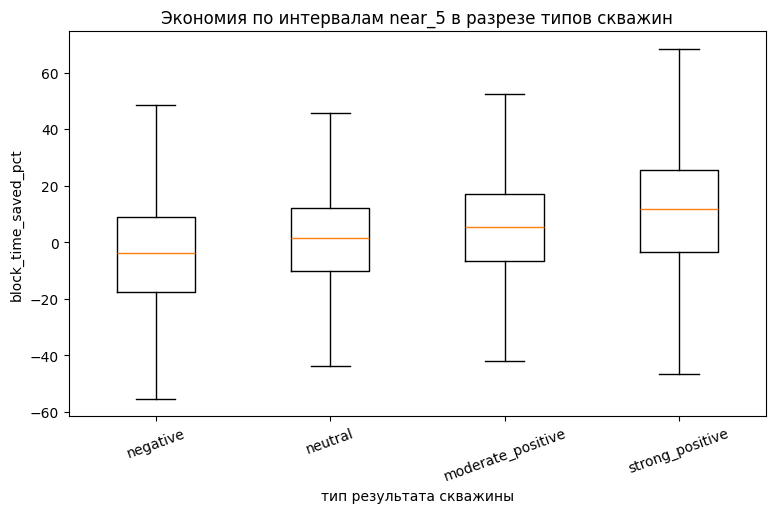

,well_id,blocks,positive_block_rate,strong_positive_block_rate,negative_block_rate,block_time_saved_pct_std,block_time_saved_pct_median,performance_type,time_saved_pct
0,19677,40,0.425000,0.375000,0.575000,19.357665,-4.230366,neutral,-1.911423
1,19720,67,0.537313,0.462687,0.462687,27.426868,3.710659,moderate_positive,4.045857
2,19775,53,0.622642,0.528302,0.377358,33.261051,7.635373,neutral,0.383467
3,19780,44,0.522727,0.386364,0.477273,29.886116,0.487466,negative,-4.058808
4,19789,49,0.632653,0.510204,0.367347,24.482068,6.613943,moderate_positive,8.923347


,performance_type,wells,positive_block_rate,strong_positive_block_rate,negative_block_rate,block_time_saved_pct_std
0,negative,31,0.428571,0.300000,0.571429,20.541664
1,neutral,137,0.542857,0.403509,0.457143,18.682812
2,moderate_positive,163,0.616279,0.510638,0.383721,19.758638
3,strong_positive,96,0.695652,0.613961,0.304348,24.366936


In [13]:
if block_df is not None:
    # Add the well-level type to each non-overlap block.
    block_df = block_df.merge(
        well_df[["well_id", "performance_type"]],
        on="well_id",
        how="left",
    )

    block_metrics = [
        "block_time_saved_pct",
        "model_based_predicted_uplift_pct",
        "predicted_regret_vs_operator_pct",
        "recommended_win_vs_operator",
        "operator_block_speed",
        "recommended_predicted_speed",
        "current_predicted_target_speed",
        "block_depth_m",
        "operator_block_time_sec",
    ]
    block_metrics = [col for col in block_metrics if col in block_df.columns]

    block_profile = (
        block_df
        .groupby("performance_type", observed=False)[block_metrics]
        .agg(["median", "mean"])
    )
    display(block_profile)
    # Merged into the combined type summary sheet later.

    if "block_time_saved_pct" in block_df.columns:
        fig = plt.figure(figsize=(9, 5))
        data = [
            block_df.loc[block_df["performance_type"] == t, "block_time_saved_pct"].dropna().to_numpy()
            for t in type_order
        ]
        plt.boxplot(data, labels=type_order, showfliers=False)
        plt.title("Экономия по интервалам near_5 в разрезе типов скважин")
        plt.xlabel("тип результата скважины")
        plt.ylabel("block_time_saved_pct")
        plt.xticks(rotation=20)
        plt.show()

    # Stability: how often blocks are positive inside each well.
    if "block_time_saved_pct" in block_df.columns:
        block_stability = (
            block_df
            .groupby("well_id")
            .agg(
                blocks=("block_time_saved_pct", "size"),
                positive_block_rate=("block_time_saved_pct", lambda s: (s > 0).mean()),
                strong_positive_block_rate=("block_time_saved_pct", lambda s: (s > 5).mean()),
                negative_block_rate=("block_time_saved_pct", lambda s: (s < 0).mean()),
                block_time_saved_pct_std=("block_time_saved_pct", "std"),
                block_time_saved_pct_median=("block_time_saved_pct", "median"),
            )
            .reset_index()
            .merge(well_df[["well_id", "performance_type", "time_saved_pct"]], on="well_id", how="left")
        )

        display(block_stability.head())
        display(
            block_stability
            .groupby("performance_type", observed=False)
            .agg(
                wells=("well_id", "size"),
                positive_block_rate=("positive_block_rate", "median"),
                strong_positive_block_rate=("strong_positive_block_rate", "median"),
                negative_block_rate=("negative_block_rate", "median"),
                block_time_saved_pct_std=("block_time_saved_pct_std", "median"),
            )
            .reset_index()
        )

        # Лист с устойчивостью интервалов удалён из Excel-отчёта.
else:
    print("Block report was not loaded; block-level analysis skipped.")

## 7. Representative wells for диплом

In [14]:
representative_rows = []

for t in type_order:
    part = well_df[well_df["performance_type"] == t].copy()
    if len(part) == 0:
        continue

    median_value = part["time_saved_pct"].median()
    part["distance_to_type_median"] = (part["time_saved_pct"] - median_value).abs()

    representative_rows.append(
        part.sort_values("distance_to_type_median").head(5)
    )

representative_wells = pd.concat(representative_rows, ignore_index=True)

cols_to_show = [
    "well_id",
    "performance_type",
    "time_saved_pct",
    "operator_time_min",
    "model_time_min",
    "total_depth_modeled_m",
    "operator_block_speed_mean",
    "recommended_predicted_speed_mean",
    "model_based_predicted_uplift_pct_median",
    "predicted_regret_vs_operator_pct_median",
    "recommended_win_vs_operator_rate",
    *energy_cols,
]

cols_to_show = [col for col in cols_to_show if col in representative_wells.columns]

display(representative_wells[cols_to_show])
add_sheet(report_tables, "03_Примеры_скважин", representative_wells[cols_to_show])

,well_id,performance_type,time_saved_pct,operator_time_min,model_time_min,total_depth_modeled_m,operator_block_speed_mean,recommended_predicted_speed_mean,model_based_predicted_uplift_pct_median,predicted_regret_vs_operator_pct_median,recommended_win_vs_operator_rate,soft_low_energy_pct,medium_low_energy_pct,medium_high_energy_pct,hard_high_energy_pct
0,22394,negative,-5.109050,11.666667,12.262722,15.3924,0.022084,0.021065,1.760557,3.536192,0.538462,100.000000,0.000000,0.000000,0.000000
1,22484,negative,-5.212349,13.733333,14.449163,17.2407,0.020947,0.019903,0.341812,-1.947120,0.433333,100.000000,0.000000,0.000000,0.000000
2,22165,negative,-4.937586,8.816667,9.251997,12.5745,0.023771,0.022738,0.557404,-1.613331,0.500000,100.000000,0.000000,0.000000,0.000000
3,22585,negative,-4.899716,8.550000,8.968926,13.1805,0.025857,0.024607,0.848842,-1.867228,0.368421,100.000000,0.000000,0.000000,0.000000
4,24320,negative,-4.638974,14.266667,14.928494,14.6652,0.017145,0.016667,1.068677,1.086898,0.531250,74.793388,25.206612,0.000000,0.000000
5,21606,neutral,0.557305,14.183333,14.104289,14.5743,0.017134,0.017302,0.593575,7.601589,0.593750,75.883576,24.116424,0.000000,0.000000
6,25753,neutral,0.582048,18.016667,17.911801,15.7257,0.014992,0.014965,1.640077,3.445091,0.641026,41.233141,42.389210,0.000000,16.377649
7,28593,neutral,0.516407,23.050000,22.930968,23.5734,0.017396,0.017275,1.150315,3.897998,0.545455,33.804627,49.614396,16.580977,0.000000
8,24568,neutral,0.503566,11.016667,10.961190,9.8172,0.015462,0.015036,0.759985,5.958123,0.652174,45.370370,54.629630,0.000000,0.000000
9,31923,neutral,0.475403,19.316667,19.224835,15.9984,0.013915,0.013982,2.571397,2.103478,0.558140,0.000000,56.439394,43.560606,0.000000


## 8. Сохранение единого Excel-отчёта

## Финальная сводка по типам скважин

Этот лист объединяет информацию, которая раньше была на листах `01`, `03` и `04`.

В нём должно быть ровно 4 строки — по одной на каждый тип результата модели.


In [15]:
# Final combined type summary.
# It is created immediately before writing Excel, so all required objects already exist:
# type_counts, pressure_profile, block_df.

combined_type_summary = type_counts.copy()

# Remove columns requested by user.
combined_type_summary = combined_type_summary.drop(
    columns=[
        "share",
        "median_time_saved_pct",
        "mean_time_saved_pct",
    ],
    errors="ignore",
)

# Add only pressure deltas from the pressure analysis.
pressure_compact = pressure_profile[
    [
        "performance_type",
        "recommended_axis_delta_pct_mean",
        "recommended_rotation_pressure_delta_pct_mean",
    ]
].copy()

combined_type_summary = combined_type_summary.merge(
    pressure_compact,
    on="performance_type",
    how="left",
)

# Add average energy-quantile composition for every performance type.
energy_cols = [
    "soft_low_energy_pct",
    "medium_low_energy_pct",
    "medium_high_energy_pct",
    "hard_high_energy_pct",
]

energy_compact = (
    well_df
    .groupby("performance_type", observed=False)[energy_cols]
    .mean()
    .reset_index()
)

combined_type_summary = combined_type_summary.merge(
    energy_compact,
    on="performance_type",
    how="left",
)

# Add only compact and useful interval-level diagnostics.
if block_df is not None:
    interval_compact = (
        block_df
        .groupby("performance_type", observed=False)
        .agg(
            intervals_count=("block_time_saved_pct", "size"),
            interval_time_saved_pct_median=("block_time_saved_pct", "median"),
            interval_time_saved_pct_mean=("block_time_saved_pct", "mean"),
            interval_model_uplift_pct_median=("model_based_predicted_uplift_pct", "median"),
            interval_regret_vs_operator_pct_median=("predicted_regret_vs_operator_pct", "median"),
            interval_recommendation_win_rate=("recommended_win_vs_operator", "mean"),
            operator_interval_speed_mean=("operator_block_speed", "mean"),
            recommended_interval_speed_mean=("recommended_predicted_speed", "mean"),
        )
        .reset_index()
    )

    combined_type_summary = combined_type_summary.merge(
        interval_compact,
        on="performance_type",
        how="left",
    )

# Guarantee exactly 4 type rows in the expected order, even if some type is empty.
expected_types = pd.DataFrame({
    "performance_type": pd.Categorical(
        ["negative", "neutral", "moderate_positive", "strong_positive"],
        categories=type_order,
        ordered=True,
    )
})

combined_type_summary = expected_types.merge(
    combined_type_summary,
    on="performance_type",
    how="left",
)

combined_type_summary = combined_type_summary.sort_values("performance_type").reset_index(drop=True)

# Put the most useful columns first.
combined_order = [
    "performance_type",
    "wells",
    "operator_time_min",
    "model_time_min",
    "time_saved_min",
    "time_saved_total_pct",
    "recommended_axis_delta_pct_mean",
    "recommended_rotation_pressure_delta_pct_mean",
    "soft_low_energy_pct",
    "medium_low_energy_pct",
    "medium_high_energy_pct",
    "hard_high_energy_pct",
    "intervals_count",
    "interval_time_saved_pct_median",
    "interval_time_saved_pct_mean",
    "interval_model_uplift_pct_median",
    "interval_regret_vs_operator_pct_median",
    "interval_recommendation_win_rate",
    "operator_interval_speed_mean",
    "recommended_interval_speed_mean",
]

combined_order = [col for col in combined_order if col in combined_type_summary.columns]
combined_type_summary = combined_type_summary[combined_order]

add_sheet(report_tables, "01_Сводка_по_типам", combined_type_summary)

print("Combined type summary rows:", len(combined_type_summary))
display(make_excel_friendly(combined_type_summary))


Combined type summary rows: 4


,Тип результата модели,Количество скважин,"Время оператора, мин","Расчётное время модели, мин","Расчётная экономия времени, мин","Суммарная расчётная экономия, %","Среднее изменение осевого давления, %","Среднее изменение давления вращения, %","Доля мягкой низкоэнергоёмкой породы, %","Доля средней низкоэнергоёмкой породы, %","Доля средней высокоэнергоёмкой породы, %","Доля твёрдой высокоэнергоёмкой породы, %",Количество интервалов near_5,"Медианная экономия по интервалам, %","Средняя экономия по интервалам, %","Медианный uplift модели по интервалам, %","Медианное отличие рекомендации от факта по интервалам, %","Доля интервалов, где рекомендация выше факта","Средняя скорость оператора по интервалам, м/с","Средняя прогнозная скорость рекомендации по интервалам, м/с"
0,Отрицательный эффект,31,357.866667,378.521381,-20.654715,-5.771623,1.847699,-0.439201,82.937072,14.169819,2.893109,0.000000,797,-3.711437,-6.134586,0.974107,-3.469474,0.424090,0.020010,0.019065
1,Нейтральный эффект,137,2428.566667,2409.593778,18.972889,0.781238,-0.064872,1.510384,49.513624,29.502247,15.539748,5.444382,5203,1.376683,0.188286,1.264868,1.395887,0.539304,0.015979,0.016047
2,Умеренно положительный эффект,163,3928.183333,3686.936849,241.246484,6.141426,-0.477720,3.457257,23.342661,30.276294,27.939274,18.441771,8183,5.452786,4.560091,2.127917,5.767254,0.621288,0.012427,0.013019
3,Сильно положительный эффект,96,2778.866667,2372.986107,405.880560,14.605975,-0.348228,4.278464,19.263837,17.653120,20.100725,42.982318,5260,11.897655,10.342654,2.971751,13.504312,0.701901,0.009563,0.010590


In [16]:
# Save all analysis tables into one Excel workbook.
# Separate CSV files are intentionally not created.

sheet_order = [
    "00_Сводка",
    "01_Сводка_по_типам",
    "02_Все_скважины",
    "03_Примеры_скважин",
]

with pd.ExcelWriter(EXCEL_REPORT_PATH, engine="openpyxl") as writer:
    for sheet_name in sheet_order:
        if sheet_name not in report_tables:
            continue

        table = report_tables[sheet_name].copy()
        table.to_excel(writer, sheet_name=sheet_name, index=False)

        ws = writer.book[sheet_name]
        ws.freeze_panes = "A2"

        # Header style and readable layout.
        for cell in ws[1]:
            cell.font = cell.font.copy(bold=True)
            cell.alignment = cell.alignment.copy(wrap_text=True, horizontal="center", vertical="center")

        for column_cells in ws.columns:
            max_len = 0
            column_letter = column_cells[0].column_letter

            for cell in column_cells[:2000]:
                value = cell.value
                if value is None:
                    continue
                max_len = max(max_len, len(str(value)))

            ws.column_dimensions[column_letter].width = min(max(max_len + 2, 12), 38)

        # Human-readable number formats.
        for row in ws.iter_rows(min_row=2):
            for cell in row:
                header = ws.cell(row=1, column=cell.column).value or ""
                if isinstance(cell.value, (int, float)):
                    header_str = str(header).lower()
                    if "скорость" in header_str or "м/с" in header_str:
                        cell.number_format = "0.000000"
                    elif "%" in str(header) or "Доля" in str(header) or "rate" in str(header):
                        cell.number_format = "0.00"
                    elif "мин" in header_str or "давление" in header_str or "проходка" in header_str:
                        cell.number_format = "0.000"
                    else:
                        cell.number_format = "0.00"

print("Saved Excel report:", EXCEL_REPORT_PATH)
print("Sheets:", [name for name in sheet_order if name in report_tables])

Saved Excel report: C:\Users\qa1ro\OneDrive\Рабочий стол\diploma\OptimalDrilling\notebooks\well_performance_analysis_reports\well_performance_analysis_report.xlsx
Sheets: ['00_Сводка', '01_Сводка_по_типам', '02_Все_скважины', '03_Примеры_скважин']
